<a href="https://colab.research.google.com/github/sabanasersaleem-oss/QSmartGrid-Quantum-AI/blob/main/UntiQSmartGrid_Quantum_Optimization_ipynbtled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 76.7 MB/s eta 0:00:00
🔹 Quantum Environment Test:
0: ───H───M('m')───

Test Simulation Results:
 m=0001000010


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


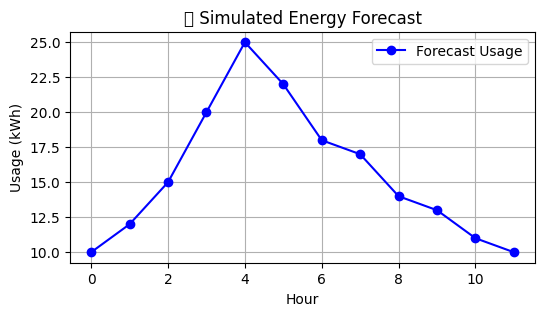


🔹 QAOA Quantum Circuit:
0: ───H───Rz(0.25π)───Rx(0.333π)───M('result')───
                                   │
1: ───H───Rz(0.25π)───Rx(0.333π)───M─────────────
                                   │
2: ───H───Rz(0.25π)───Rx(0.333π)───M─────────────


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


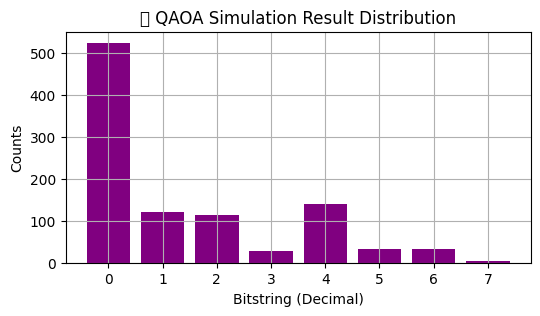


Original vs Optimized Energy Usage (Sample):
Hour 00:    10 →   8.0
Hour 01:    12 →   9.6
Hour 02:    15 →  12.0
Hour 03:    20 →  16.0
Hour 04:    25 →  20.0
Hour 05:    22 →  17.6
Hour 06:    18 →  14.4
Hour 07:    17 →  13.6
Hour 08:    14 →  11.2
Hour 09:    13 →  10.4
Hour 10:    11 →   8.8
Hour 11:    10 →   8.0

✅ optimized_results.csv saved successfully.


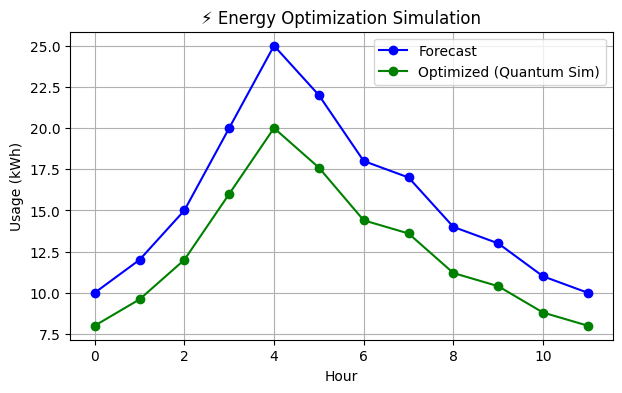

In [1]:
# ============================================
# ⚡ QSmartGrid – Quantum Optimization Prototype (Cirq + QAOA)
# Team QVision | Saba Saleem – Quantum Lead
# ============================================

# 1️⃣ Install & Import Libraries
!pip install cirq --quiet
import cirq
import numpy as np
import matplotlib.pyplot as plt

# 2️⃣ Test Environment
q0 = cirq.LineQubit(0)
test_circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.measure(q0, key='m')
)
print("🔹 Quantum Environment Test:")
print(test_circuit)

sim = cirq.Simulator()
test_result = sim.run(test_circuit, repetitions=10)
print("\nTest Simulation Results:\n", test_result)

# 3️⃣ Simulated AI Forecast Data (temporary until real data from team)
forecast_usage = np.array([10, 12, 15, 20, 25, 22, 18, 17, 14, 13, 11, 10])
hours = np.arange(len(forecast_usage))

plt.figure(figsize=(6,3))
plt.plot(hours, forecast_usage, marker='o', color='blue', label="Forecast Usage")
plt.title("📊 Simulated Energy Forecast")
plt.xlabel("Hour")
plt.ylabel("Usage (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# 4️⃣ Build Simplified QAOA Circuit
qubits = [cirq.LineQubit(i) for i in range(3)]
circuit = cirq.Circuit()

# Initial superposition
for q in qubits:
    circuit.append(cirq.H(q))

# Cost layer (Z rotations)
for q in qubits:
    circuit.append(cirq.rz(np.pi / 4)(q))

# Mixer layer (X rotations)
for q in qubits:
    circuit.append(cirq.rx(np.pi / 3)(q))

# Measurement
circuit.append(cirq.measure(*qubits, key='result'))

print("\n🔹 QAOA Quantum Circuit:")
print(circuit)

# 5️⃣ Run Simulation
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=1000)
hist = result.histogram(key='result')

# 6️⃣ Visualize Probability Distribution
plt.figure(figsize=(6,3))
plt.bar(hist.keys(), hist.values(), color='purple')
plt.title("🔮 QAOA Simulation Result Distribution")
plt.xlabel("Bitstring (Decimal)")
plt.ylabel("Counts")
plt.grid(True)
plt.show()

# 7️⃣ Simulate Optimization Effect (reduce 20%)
optimized_usage = forecast_usage * 0.8
print("\nOriginal vs Optimized Energy Usage (Sample):")
for i in range(len(forecast_usage)):
    print(f"Hour {i:02d}: {forecast_usage[i]:>5} → {optimized_usage[i]:>5.1f}")

# 8️⃣ Save Results
np.savetxt("optimized_results.csv", optimized_usage, delimiter=",")
print("\n✅ optimized_results.csv saved successfully.")

# 9️⃣ Optional: Plot Comparison
plt.figure(figsize=(7,4))
plt.plot(hours, forecast_usage, '-o', label="Forecast", color='blue')
plt.plot(hours, optimized_usage, '-o', label="Optimized (Quantum Sim)", color='green')
plt.title("⚡ Energy Optimization Simulation")
plt.xlabel("Hour")
plt.ylabel("Usage (kWh)")
plt.legend()
plt.grid(True)
plt.show()
